In [19]:
import re
import pandas as pd

# marker regex
marker_pattern = re.compile(r"%---- Page End Break Here ---- Page : (\d+)")

def split_by_pages(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        text = f.read()
    
    # split into chunks with markers
    parts = re.split(marker_pattern, text)
    
    # first element before page 1 might be junk
    data = {}
    for i in range(1, len(parts), 2):
        page_num = int(parts[i])
        page_text = parts[i+1]
        data[page_num] = {
            "chars": len(page_text),
            "words": len(page_text.split()),
            "lines": len(page_text.splitlines())
        }
    return data

# Process both versions
original_data = split_by_pages("../../files/algorithms_book/outputs/algorithms_pg_sep.tex")
processed_data = split_by_pages("../../files/algorithms_book/outputs/algorithms_final_indexed.tex")

# Merge into a DataFrame
df = pd.DataFrame.from_dict(original_data, orient="index")
df_proc = pd.DataFrame.from_dict(processed_data, orient="index")

df = df.join(df_proc, lsuffix="_orig", rsuffix="_proc")

# Calculate differences
df["char_diff"] = df["chars_proc"] - df["chars_orig"]
df["char_ratio"] = df["chars_proc"] / df["chars_orig"]

# print(df.head())

# Basic statistics
print(df.describe())

         chars_orig   words_orig   lines_orig    chars_proc   words_proc  \
count    630.000000   630.000000   630.000000    630.000000   630.000000   
mean    3059.239683   479.500000    30.530159   3257.296825   502.955556   
std     1780.468340   271.618418    48.973614   1772.393875   278.641306   
min       27.000000     3.000000     2.000000      1.000000     0.000000   
25%     2159.250000   345.000000    15.000000   2244.750000   351.250000   
50%     2759.500000   432.000000    22.000000   2867.500000   440.500000   
75%     3186.750000   518.750000    35.000000   3406.000000   544.500000   
max    27012.000000  3742.000000  1050.000000  18783.000000  2735.000000   

       lines_proc     char_diff  char_ratio  
count  630.000000    630.000000  630.000000  
mean    32.895238    198.057143    1.085352  
std     29.093487   1332.388262    0.288663  
min      1.000000 -27011.000000    0.000037  
25%     17.000000      0.000000    1.000000  
50%     25.000000     43.500000    1.01

In [20]:
(df.head())

,chars_orig,words_orig,lines_orig,chars_proc,words_proc,lines_proc,char_diff,char_ratio
2,1374,202,8,1458,205,7,84,1.061135
3,4350,612,40,4467,614,38,117,1.026897
6,2711,415,28,2975,417,28,264,1.097381
7,2798,435,17,2906,435,18,108,1.038599
8,2303,373,17,2310,373,17,7,1.003040


In [21]:
high_ratio_pages = df[df["char_ratio"] > 1.4]


print(f"Total pages with ratio > 1.2: {len(high_ratio_pages)}")
(high_ratio_pages.head())

Total pages with ratio > 1.2: 41


,chars_orig,words_orig,lines_orig,chars_proc,words_proc,lines_proc,char_diff,char_ratio
50,2688,446,19,4080,649,24,1392,1.517857
51,1475,223,18,2814,446,31,1339,1.907797
81,2383,321,45,4342,692,78,1959,1.822073
86,2735,454,22,4904,816,40,2169,1.793053
89,1683,281,36,2482,410,51,799,1.474747


In [22]:
print(df["char_ratio"].describe())


count    630.000000
mean       1.085352
std        0.288663
min        0.000037
25%        1.000000
50%        1.017016
75%        1.039002
max        5.259259
Name: char_ratio, dtype: float64


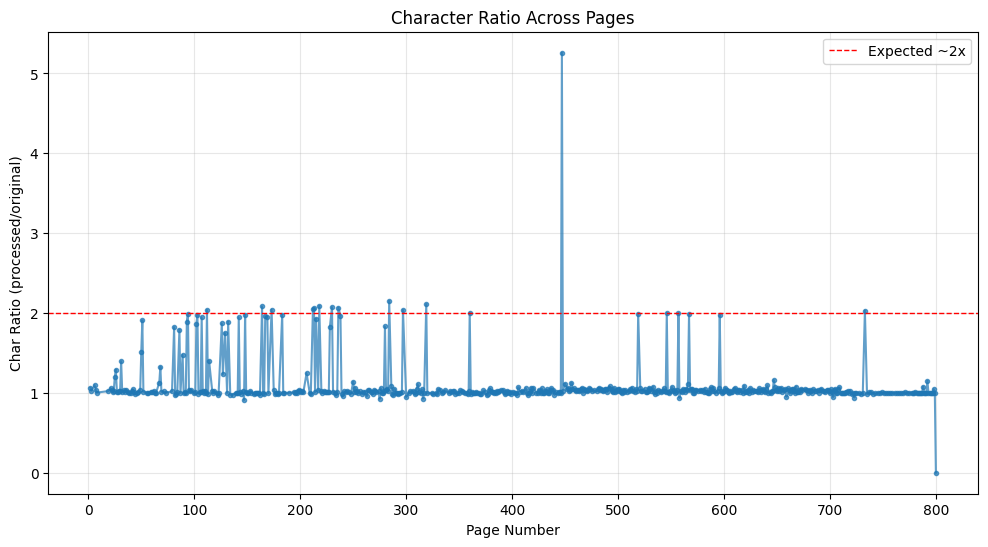

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df.index, df["char_ratio"], marker=".", linestyle="-", alpha=0.7)

# Highlight baseline
plt.axhline(y=2, color="red", linestyle="--", linewidth=1, label="Expected ~2x")

plt.xlabel("Page Number")
plt.ylabel("Char Ratio (processed/original)")
plt.title("Character Ratio Across Pages")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [18]:
df.loc[97]


chars_orig    4896.000000
words_orig     770.000000
lines_orig      75.000000
chars_proc    7628.000000
words_proc    1189.000000
lines_proc     120.000000
char_diff     2732.000000
char_ratio       1.558007
Name: 97, dtype: float64

In [17]:
proc = 7508
orig = 4821

proc / orig

1.5573532462144783